# PCA: Finding the Directions Your Data Actually Varies Along

Principal Component Analysis answers one question: if you had to describe a cloud of points using as few directions as possible, which directions would you pick? This notebook builds PCA from a covariance matrix and its eigenvectors, first on a synthetic 2D cloud where you can see the answer, then on a real 30-feature dataset where you can't.

## The math

Given data $X \in \mathbb{R}^{N \times D}$ (rows are samples):

1. Center it: $\tilde{X} = X - \bar{x}$
2. Compute the covariance matrix: $C = \frac{1}{N-1}\tilde{X}^T\tilde{X}$
3. Eigendecompose $C$: $Cv_i = \lambda_i v_i$
4. Sort eigenvectors by eigenvalue, descending. The top eigenvector points along the direction of maximum variance; each eigenvalue is how much variance lies along that direction.

Projecting onto the top $k$ eigenvectors gives the best $k$-dimensional summary of the data (in a least-squares sense).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from linalg_playground.pca import pca, project

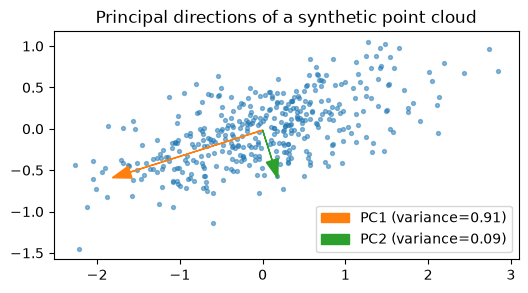

In [2]:
rng = np.random.default_rng(42)
n = 400
t = rng.normal(size=n)
noise = rng.normal(scale=0.3, size=n)
direction = np.array([3.0, 1.0]) / np.linalg.norm([3.0, 1.0])
perpendicular = np.array([-direction[1], direction[0]])
cloud = np.outer(t, direction) + np.outer(noise, perpendicular)

mean, eigenvalues, eigenvectors = pca(cloud)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(cloud[:, 0], cloud[:, 1], s=8, alpha=0.5)
for i in range(2):
    v = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 2
    ax.arrow(mean[0], mean[1], v[0], v[1], head_width=0.15,
              length_includes_head=True, color=f"C{i+1}",
              label=f"PC{i+1} (variance={eigenvalues[i]:.2f})")
ax.set_aspect("equal")
ax.legend()
ax.set_title("Principal directions of a synthetic point cloud")
plt.show()

## A real dataset: 30 features down to 2

The Breast Cancer Wisconsin dataset has 30 measured features per sample. We can't plot 30 dimensions, but we can project onto the top 2 principal components and see how much of the data's structure survives.

Top 2 components explain 99.8% of total variance


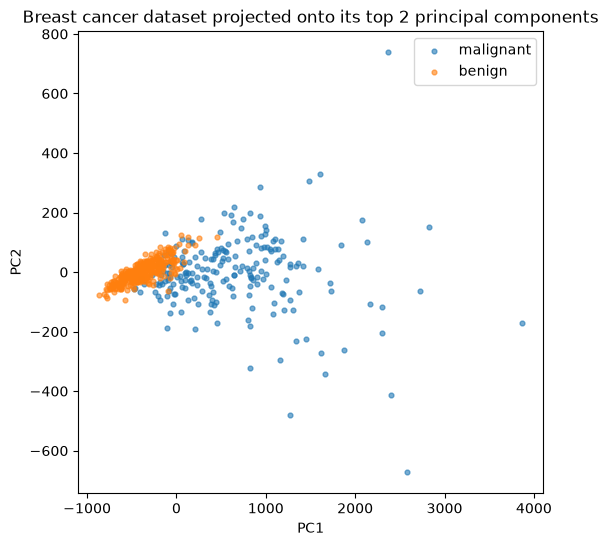

In [3]:
data = load_breast_cancer()
X, y = data.data, data.target

mean, eigenvalues, eigenvectors = pca(X)
projected = project(X, mean, eigenvectors, n_components=2)

explained = eigenvalues[:2].sum() / eigenvalues.sum()
print(f"Top 2 components explain {explained:.1%} of total variance")

fig, ax = plt.subplots(figsize=(6, 6))
for label, name in zip([0, 1], data.target_names):
    mask = y == label
    ax.scatter(projected[mask, 0], projected[mask, 1], s=12, alpha=0.6, label=name)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
ax.set_title("Breast cancer dataset projected onto its top 2 principal components")
plt.show()

## Takeaway

PCA is a change of basis: instead of describing points using the original feature axes, we describe them using the eigenvectors of the covariance matrix -- axes chosen so the first few capture as much of the data's spread as possible. That's the same eigenvector idea from the transform playground notebook, just applied to a covariance matrix instead of an arbitrary transform.